In [11]:
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def smoother(x, a=0.9, w=1, mode="window"):
    if mode == "moving":
        y = [x[0]]
        for i in range(1, len(x)):
            y.append((1 - a) * x[i] + a * y[i - 1])
    elif mode == "window":
        y = []
        for i in range(len(x)):
            y.append(np.mean(x[max(i - w, 0) : i + 1]))
    else:
        raise NotImplementedError
    return y


def process_data(learning_data, scale=1.0):
    N = np.min([len(df) for df in learning_data])
    ys = [smoother(np.asarray(df)[:N], w=80, mode="window") for df in learning_data]
    x = np.arange(0, N) * scale
    return x, np.asarray(ys)


def sub_figure(ax, x, ys, label=None, color=None, **plot_kwargs):
    y_mean = np.mean(ys, axis=0)
    y_std = np.std(ys, axis=0)
    ax.plot(x, y_mean, color=color, label=label, **plot_kwargs)
    ax.fill_between(x, y_mean - y_std, y_mean + y_std, color=color, alpha=0.2)
    print(y_mean[-1], y_std[-1], label)


def convert_tb_data(root_dir, sort_by=None):
    """Convert local TensorBoard data into Pandas DataFrame.
    
    Function takes the root directory path and recursively parses
    all events data.    
    If the `sort_by` value is provided then it will use that column
    to sort values; typically `wall_time` or `step`.
    
    *Note* that the whole data is converted into a DataFrame.
    Depending on the data size this might take a while. If it takes
    too long then narrow it to some sub-directories.
    
    Paramters:
        root_dir: (str) path to root dir with tensorboard data.
        sort_by: (optional str) column name to sort by.
    
    Returns:
        pandas.DataFrame with [wall_time, name, step, value] columns.
    
    """
    from tensorflow.python.summary.summary_iterator import summary_iterator

    def convert_tfevent(filepath):
        return pd.DataFrame([
            parse_tfevent(e) for e in summary_iterator(filepath) if len(e.summary.value)
        ])

    def parse_tfevent(tfevent):
        return dict(
            wall_time=tfevent.wall_time,
            name=tfevent.summary.value[0].tag,
            step=tfevent.step,
            value=float(tfevent.summary.value[0].simple_value),
        )
    
    columns_order = ['wall_time', 'name', 'step', 'value']
    
    out = []
    for (root, _, filenames) in os.walk(root_dir):
        for filename in filenames:
            if "events.out.tfevents" not in filename:
                continue
            file_full_path = os.path.join(root, filename)
            out.append(convert_tfevent(file_full_path))

    # Concatenate (and sort) all partial individual dataframes
    # print(out)
    all_df = pd.concat(out)[columns_order]
    if sort_by is not None:
        all_df = all_df.sort_values(sort_by)
        
    return all_df.reset_index(drop=True)

def load_all_learning_data(exp_names=None):
    all_data_dict = {}
    for exp_name, v in exp_names.items():
        env_i_all_algs_data_dict = {}
        for alg_name in v:
            print(alg_name)
            env_i_algo_j_learning_data = []
            for seed in os.listdir(f"runs_total_control_2/{alg_name}"):
                ss = convert_tb_data(f"runs_total_control_2/{alg_name}/{seed}")
                ss = ss.loc[ss["name"] == "average_episode_rewards"]
                env_i_algo_j_learning_data.append(ss["value"].values)
            env_i_all_algs_data_dict[alg_name] = env_i_algo_j_learning_data
        all_data_dict[exp_name] = env_i_all_algs_data_dict
    return all_data_dict, len(exp_names)

"""
----------------------plot function----------------------

"""
legend_font = {"style": "normal", "size": 12, "weight": "normal"}# font of legend


def plot_curves(all_data_dict, num_task, num_colors=9):
    sns.set_theme(#TODO main theme of 
        style="darkgrid",
        font_scale=1.15,
        # font="Times New Roman",
        rc={"figure.figsize": (4.6, 4.6)},#TODO change shape of figure here
    )
    COLORS = sns.color_palette("Set1", num_colors, 0.9)
    fig = plt.figure(dpi=300)
    fig_task_id = 1
    for exp_name, value in all_data_dict.items():
        ax = fig.add_subplot(1, num_task, fig_task_id)#TODO add subfigure by rows and columns here
        color_id = 0
        for alg_name, learning_data in value.items():
            x, ys = process_data(learning_data, scale=1.)
            print(exp_name, alg_name)
            sub_figure(ax, x, ys, label=alg_name, color=COLORS[color_id])
            color_id += 1
        ax.set_title(exp_name)
        ax.set_xlim(x[0], x[-1])
        ax.set_xlabel("Episodes")
        if fig_task_id == 1:
            ax.set_ylabel("Average Reward")
        ax.legend(
            loc="lower right",
            prop=legend_font,
        )
        fig_task_id += 1
    plt.tight_layout()
    plt.savefig("./img/sim_ppo.pdf", bbox_inches='tight')
    plt.show()

ppo
acpo
Control ppo
-427.1705606719594 0.0 ppo
Control acpo
-181.48747159227912 0.0 acpo


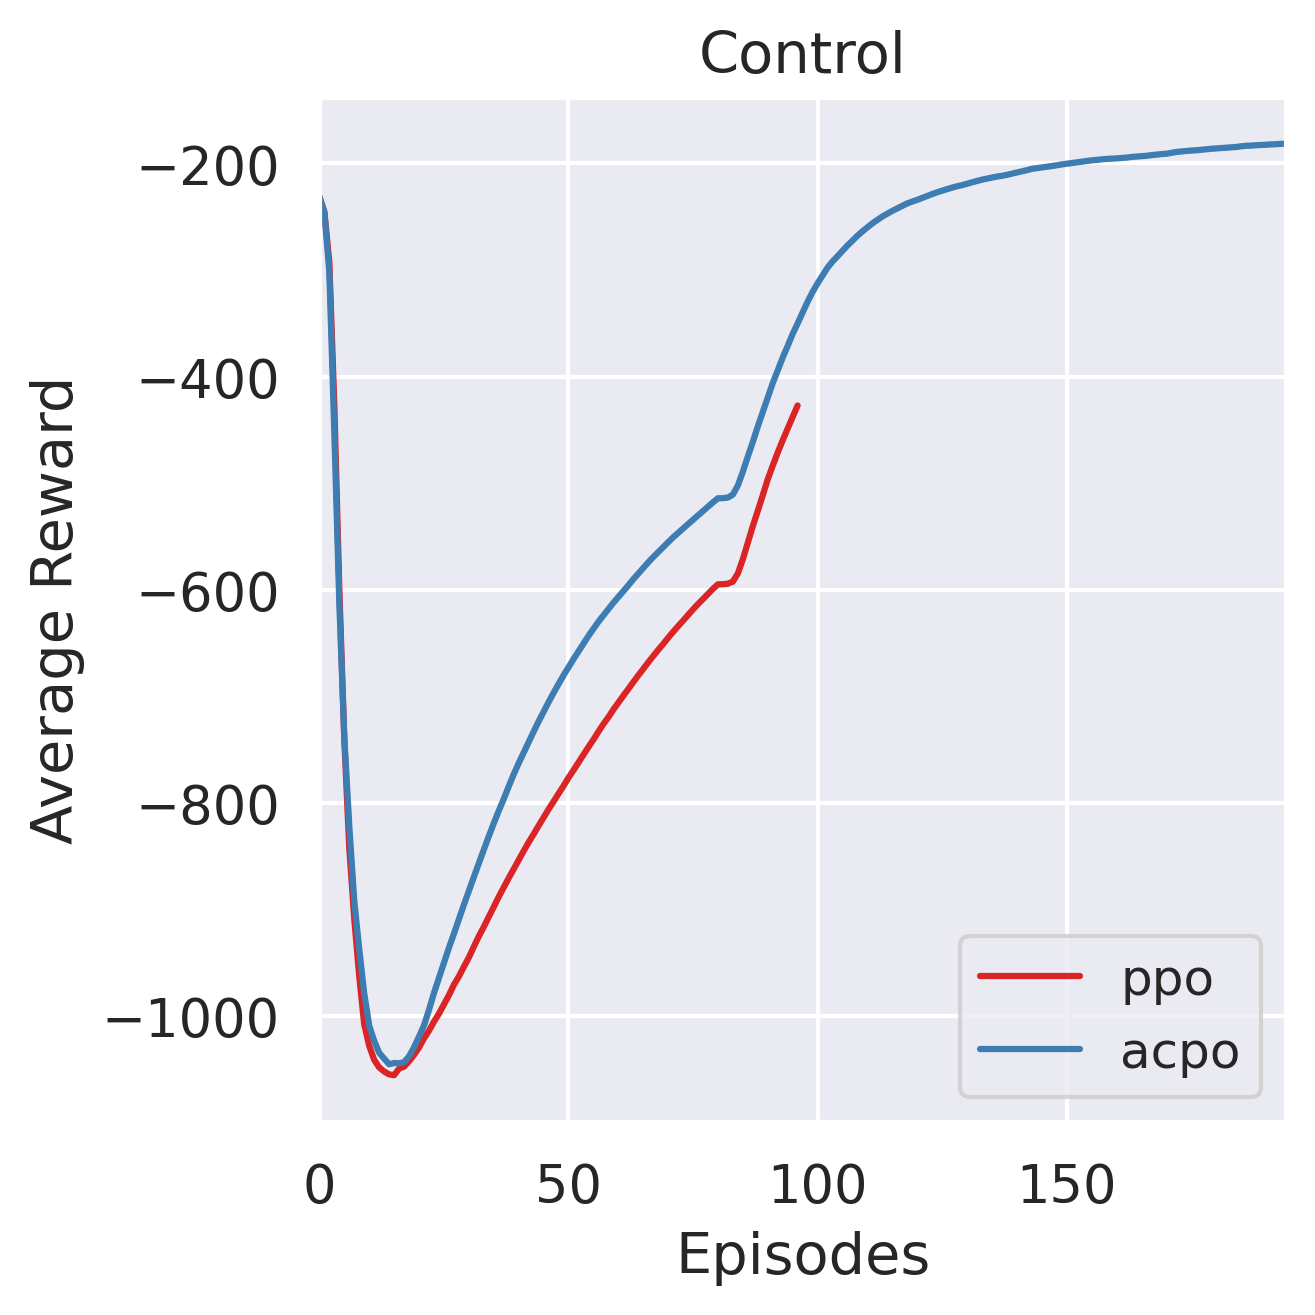

In [13]:
"""
期望的目录格式（需要手动分类）：
--runs_total
  --airspeed 10
    --2024-05-04_15-14-09_Control_heading_ppo_v1
    --2024-05-20_20-40-09_Control_heading_ppo_v1
  --airspeed 30
  ...
  --normal
  --vt 800-900

exp_names中的key为子图的标题，value为子目录/实验名legend，要求与上述目录格式对应；
"""


# exp_names = {
#     "Airspeed": ["normal","airspeed 30"],
#     "Altitude": ["normal", "altitude 29000-30000"],
#     "Noise": ["normal","noise 0.01"],
#     "Velocity": ["normal","vt 800-900"],
# }
# exp_names = {"Roll out thrends": ["32", "256", "3000"], "Model": ["F16", "UAV"]}
exp_names = {"Control": ["ppo", "acpo"]}
all_datadict, N_exps = load_all_learning_data(exp_names)
plot_curves(all_datadict, N_exps)